In [6]:
!pip install vaderSentiment
!pip install wordcloud
print("✅ Done!")

✅ Done!


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries imported!")


✅ Libraries imported!


In [8]:
url = "https://raw.githubusercontent.com/pycaret/pycaret/master/datasets/amazon.csv"
df = pd.read_csv(url)

# Rename to simple names
df = df.rename(columns={'reviewText': 'Review',
                         'Positive': 'Rating'})

print("✅ Dataset loaded!")
print("Shape:", df.shape)
df.head()

✅ Dataset loaded!
Shape: (20000, 2)


,Review,Rating
0,This is a one of the best apps acording to a b...,1
1,This is a pretty good version of the game for ...,1
2,this is a really cool game. there are a bunch ...,1
3,"This is a silly game and can be frustrating, b...",1
4,This is a terrific game on any pad. Hrs of fun...,1


In [9]:
print("=" * 40)
print("DATASET INFORMATION")
print("=" * 40)
print("\n📌 Shape:", df.shape)
print("\n📌 Columns:", df.columns.tolist())
print("\n📌 Missing Values:\n", df.isnull().sum())
print("\n📌 Rating Distribution:")
print(df['Rating'].value_counts())
print("\n📌 Sample Review:")
print(df['Review'].iloc[0])

DATASET INFORMATION

📌 Shape: (20000, 2)

📌 Columns: ['Review', 'Rating']

📌 Missing Values:
 Review    0
Rating    0
dtype: int64

📌 Rating Distribution:
Rating
1    15233
0     4767
Name: count, dtype: int64

📌 Sample Review:
This is a one of the best apps acording to a bunch of people and I agree it has bombs eggs pigs TNT king pigs and realustic stuff


In [10]:
df = df.dropna(subset=['Review'])
df = df.reset_index(drop=True)
df = df.head(2000)

print("✅ Data cleaned!")
print("Total reviews:", len(df))

✅ Data cleaned!
Total reviews: 2000


In [11]:
analyzer = SentimentIntensityAnalyzer()

def get_sentiment(text):
    score = analyzer.polarity_scores(str(text))['compound']
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

def get_score(text):
    return analyzer.polarity_scores(str(text))['compound']

df['Sentiment'] = df['Review'].apply(get_sentiment)
df['Sentiment_Score'] = df['Review'].apply(get_score)

print("✅ Sentiment Analysis Done!")
print("\n📊 Sentiment Count:")
print(df['Sentiment'].value_counts())
df.head()

✅ Sentiment Analysis Done!

📊 Sentiment Count:
Sentiment
Positive    1599
Negative     320
Neutral       81
Name: count, dtype: int64


,Review,Rating,Sentiment,Sentiment_Score
0,This is a one of the best apps acording to a b...,1,Positive,0.7717
1,This is a pretty good version of the game for ...,1,Positive,0.9325
2,this is a really cool game. there are a bunch ...,1,Positive,0.8687
3,"This is a silly game and can be frustrating, b...",1,Positive,0.9413
4,This is a terrific game on any pad. Hrs of fun...,1,Positive,0.9552


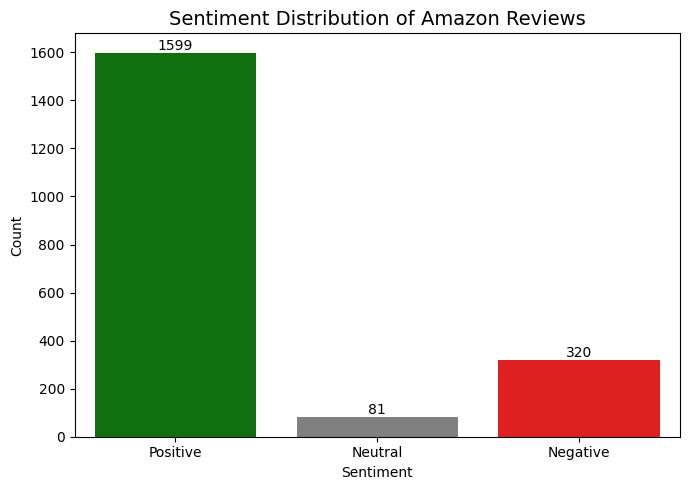

📌 Insight: Majority of reviews are Positive


In [12]:
plt.figure(figsize=(7,5))
sns.countplot(x='Sentiment', data=df,
              order=['Positive','Neutral','Negative'],
              palette={'Positive':'green',
                       'Neutral':'gray',
                       'Negative':'red'})
plt.title('Sentiment Distribution of Amazon Reviews',
          fontsize=14)
plt.xlabel('Sentiment')
plt.ylabel('Count')
for p in plt.gca().patches:
    plt.gca().annotate(f'{int(p.get_height())}',
                      (p.get_x() + p.get_width()/2,
                       p.get_height()),
                      ha='center', va='bottom')
plt.tight_layout()
plt.savefig('sa1_sentiment_distribution.png')
plt.show()
print("📌 Insight: Majority of reviews are Positive")

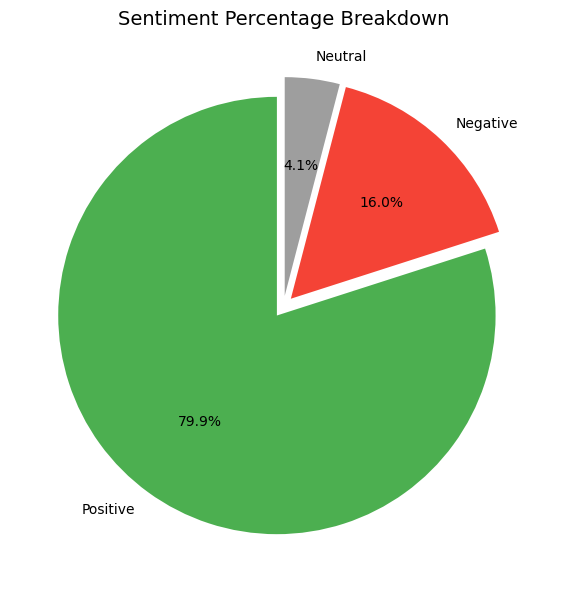

📌 Insight: Percentage of each sentiment category


In [13]:
plt.figure(figsize=(6,6))
counts = df['Sentiment'].value_counts()
plt.pie(counts,
        labels=counts.index,
        autopct='%1.1f%%',
        colors=['#4CAF50','#F44336','#9E9E9E'],
        explode=[0.05]*len(counts),
        startangle=90)
plt.title('Sentiment Percentage Breakdown', fontsize=14)
plt.tight_layout()
plt.savefig('sa2_sentiment_pie.png')
plt.show()
print("📌 Insight: Percentage of each sentiment category")

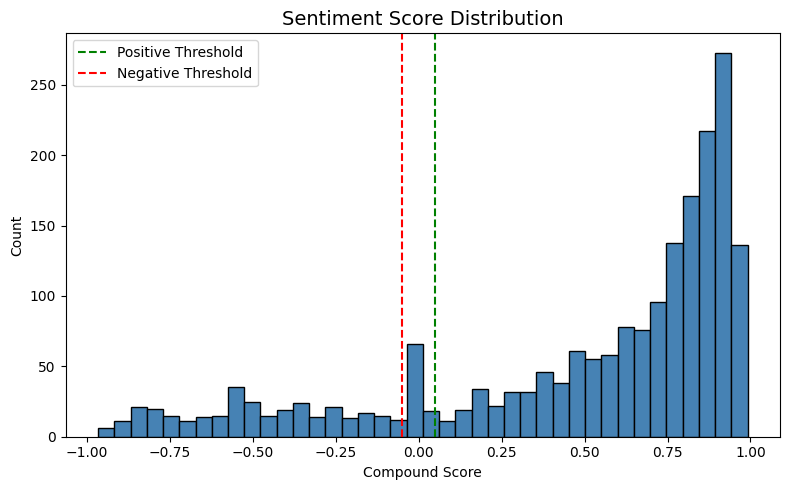

📌 Insight: Most scores lean positive (above 0)


In [14]:
plt.figure(figsize=(8,5))
plt.hist(df['Sentiment_Score'], bins=40,
         color='steelblue', edgecolor='black')
plt.axvline(x=0.05, color='green',
            linestyle='--', label='Positive Threshold')
plt.axvline(x=-0.05, color='red',
            linestyle='--', label='Negative Threshold')
plt.title('Sentiment Score Distribution', fontsize=14)
plt.xlabel('Compound Score')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.savefig('sa3_score_distribution.png')
plt.show()
print("📌 Insight: Most scores lean positive (above 0)")

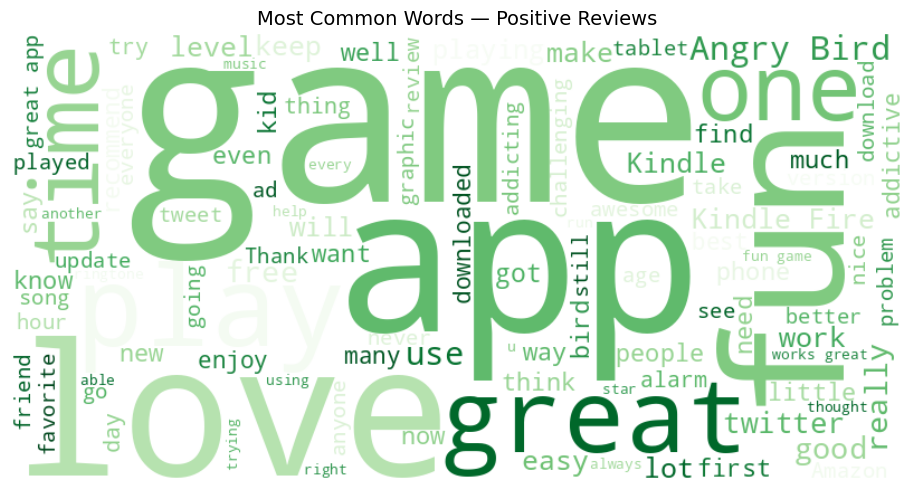

📌 Insight: Common words in positive reviews


In [15]:
positive_text = " ".join(
    df[df['Sentiment']=='Positive']['Review'].astype(str))

wc = WordCloud(width=800, height=400,
               background_color='white',
               colormap='Greens',
               max_words=100).generate(positive_text)

plt.figure(figsize=(10,5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words — Positive Reviews',
          fontsize=14)
plt.tight_layout()
plt.savefig('sa4_positive_wordcloud.png')
plt.show()
print("📌 Insight: Common words in positive reviews")

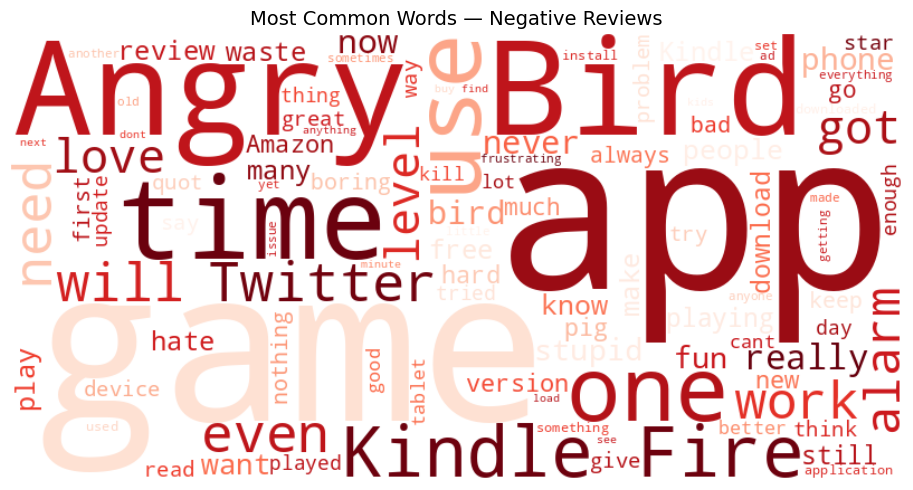

📌 Insight: Common words in negative reviews


In [16]:
negative_text = " ".join(
    df[df['Sentiment']=='Negative']['Review'].astype(str))

wc_neg = WordCloud(width=800, height=400,
                   background_color='white',
                   colormap='Reds',
                   max_words=100).generate(negative_text)

plt.figure(figsize=(10,5))
plt.imshow(wc_neg, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words — Negative Reviews',
          fontsize=14)
plt.tight_layout()
plt.savefig('sa5_negative_wordcloud.png')
plt.show()
print("📌 Insight: Common words in negative reviews")

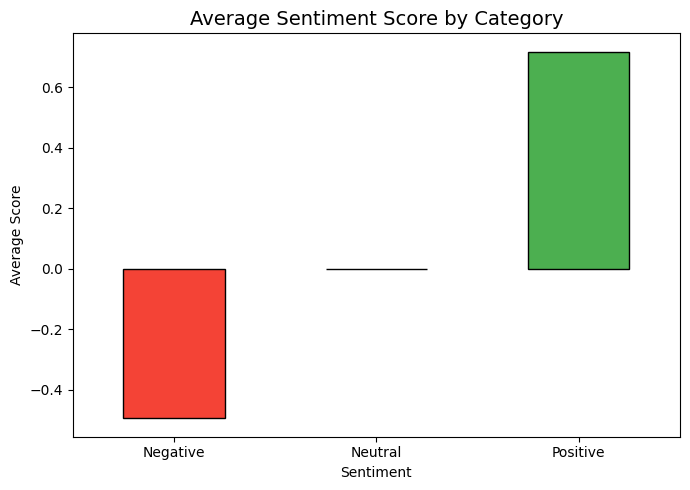

📌 Insight: Clear score gap between categories


In [17]:
plt.figure(figsize=(7,5))
order = ['Negative','Neutral','Positive']
colors = ['#F44336','#9E9E9E','#4CAF50']
means = df.groupby('Sentiment')['Sentiment_Score'].mean()
means[order].plot(kind='bar',
                  color=colors,
                  edgecolor='black')
plt.title('Average Sentiment Score by Category',
          fontsize=14)
plt.xlabel('Sentiment')
plt.ylabel('Average Score')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('sa6_avg_score.png')
plt.show()
print("📌 Insight: Clear score gap between categories")

In [18]:
total = len(df)
pos = len(df[df['Sentiment']=='Positive'])
neg = len(df[df['Sentiment']=='Negative'])
neu = len(df[df['Sentiment']=='Neutral'])

print("=" * 50)
print("📋 SENTIMENT ANALYSIS SUMMARY")
print("=" * 50)
print(f"✅ Total Reviews   : {total}")
print(f"✅ Positive        : {pos} ({pos/total*100:.1f}%)")
print(f"✅ Negative        : {neg} ({neg/total*100:.1f}%)")
print(f"✅ Neutral         : {neu} ({neu/total*100:.1f}%)")
print(f"✅ Avg Score       : {df['Sentiment_Score'].mean():.3f}")
print("=" * 50)
print("\n📌 Overall: Most Amazon reviews are Positive!")

📋 SENTIMENT ANALYSIS SUMMARY
✅ Total Reviews   : 2000
✅ Positive        : 1599 (80.0%)
✅ Negative        : 320 (16.0%)
✅ Neutral         : 81 (4.0%)
✅ Avg Score       : 0.494

📌 Overall: Most Amazon reviews are Positive!


In [19]:
from google.colab import files

charts = ['sa1_sentiment_distribution.png',
          'sa2_sentiment_pie.png',
          'sa3_score_distribution.png',
          'sa4_positive_wordcloud.png',
          'sa5_negative_wordcloud.png',
          'sa6_avg_score.png']

for chart in charts:
    files.download(chart)

print("✅ All charts downloaded!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ All charts downloaded!
